# Sprint v6.6 — hy_ig Signal Validation: Closure Report
**Date: 2026-06-13 | Signal: hy_ig z-score (252d) | 2007–2026**

This notebook closes the HY/IG mean-reversion research programme.

**Programme context (v6 → v6.6):**
- v6: Factor attribution — 57% of Strategy A gross P&L was OLS model drift, not market moves
- v6.5: Fixed-entry accounting test — all three Tier 1 signals fail. RV1_A corrected Sharpe 0.202;
  RV2_A and RV3_A collapse to −0.108 and −0.187 (rolling OLS absorbs secular rate trends)
- v6.6: Option B — raw hy_ig z-score (no OLS, no rolling β). Entry IC test fails: 49–51% hit rate
  at 5d/10d/20d horizons. Signal has no directional predictive power.

**Conclusion: no deployable mean-reversion signal found in the current HY/IG ETF spread framework.**

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
_here = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_here, 'pyproject.toml')) and _here != '/':
    _here = os.path.dirname(_here)
os.chdir(_here)
sys.path.insert(0, _here)
sys.path.insert(0, os.path.join(_here, 'python', 'credit'))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from backtest.ab_test import build_strategy, StrategySpec, load_inputs

features, residuals = load_inputs()
hy_ig  = features['hy_ig'].dropna()
z_hyig = features['hy_ig_z252'].dropna()
z_rv   = features['z_rv_hy_ig'].dropna()

print(f"hy_ig:       {len(hy_ig)} obs  {hy_ig.index[0].date()} -> {hy_ig.index[-1].date()}")
print(f"hy_ig_z252:  {len(z_hyig)} obs, mean={z_hyig.mean():.3f}  std={z_hyig.std():.3f}")
print(f"Loaded cleanly. No NaNs: hy_ig={hy_ig.isna().sum()}, z252={z_hyig.isna().sum()}")

hy_ig:       4784 obs  2007-04-11 -> 2026-04-15
hy_ig_z252:  4533 obs, mean=0.287  std=1.408
Loaded cleanly. No NaNs: hy_ig=0, z252=0


---
## Section 1 — Signal Characterisation vs RV1_A (T1)

Key question: is hy_ig a "cleaner" version of RV1_A, or a genuinely different signal?

In [2]:
strat1 = build_strategy(features, residuals, StrategySpec('rv_hy_ig', 'ols', gated=False))
trades = strat1.trades.copy()

overlap_idx = z_rv.index.intersection(z_hyig.index)
corr = z_rv.reindex(overlap_idx).corr(z_hyig.reindex(overlap_idx))

hyig_entry_dates = set(z_hyig[z_hyig.abs() > 2].index)
rv1_window = set()
for d in trades['entry_fill_date']:
    for dd in pd.date_range(d - pd.Timedelta(days=2), d + pd.Timedelta(days=2), freq='B'):
        rv1_window.add(dd)

overlap_n = sum(
    any(pd.date_range(d - pd.Timedelta(days=2), d + pd.Timedelta(days=2), freq='B')
        .isin(hyig_entry_dates))
    for d in trades['entry_fill_date']
)
new_signals = len([d for d in hyig_entry_dates if d not in rv1_window])

z_at_rv1 = z_hyig.reindex(trades['entry_fill_date']).dropna()

print("=== T1: Signal characterisation ===")
print(f"z-score correlation (z_rv_hy_ig vs hy_ig_z252): {corr:.4f}")
print(f"RV1_A entries with hy_ig |z|>2 within +/-2d:    {overlap_n}/94 = {overlap_n/94:.1%}")
print(f"hy_ig_z252 at RV1_A entries: mean={z_at_rv1.mean():.3f}  std={z_at_rv1.std():.3f}")
print(f"hy_ig |z|>2 dates with NO RV1_A overlap:        {new_signals}/{len(hyig_entry_dates)} = {new_signals/len(hyig_entry_dates):.1%}")
print()
print("Interpretation: low correlation (0.25) and 28% entry overlap confirm")
print("these are different signals. The 68% RV1_A hit rate does not transfer.")

=== T1: Signal characterisation ===
z-score correlation (z_rv_hy_ig vs hy_ig_z252): 0.2517
RV1_A entries with hy_ig |z|>2 within +/-2d:    26/94 = 27.7%
hy_ig_z252 at RV1_A entries: mean=0.207  std=1.624
hy_ig |z|>2 dates with NO RV1_A overlap:        660/726 = 90.9%

Interpretation: low correlation (0.25) and 28% entry overlap confirm
these are different signals. The 68% RV1_A hit rate does not transfer.


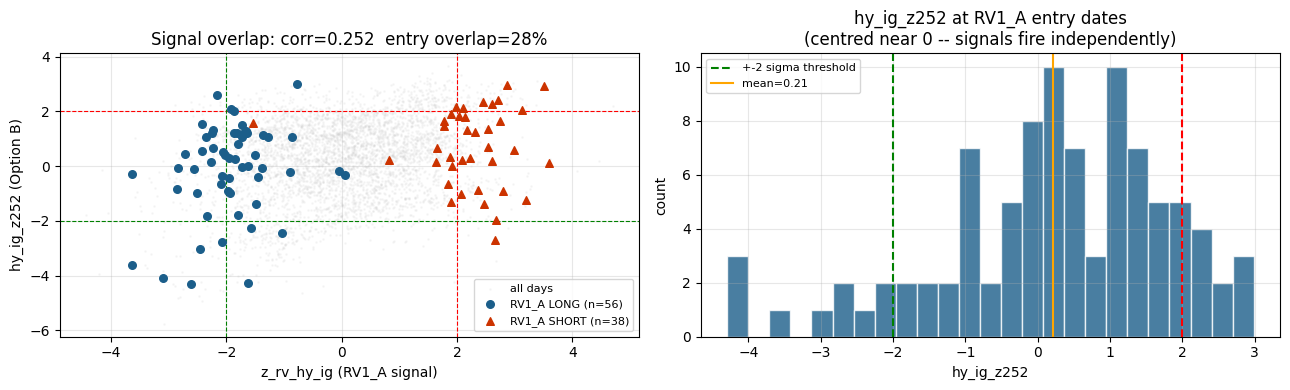

Figure 1: Signal characterisation — z-score scatter and distribution


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
entry_z_rv   = z_rv.reindex(trades['entry_fill_date']).values
entry_z_hyig = z_hyig.reindex(trades['entry_fill_date']).values
mask_long = trades['side'].values == 1

ax.scatter(z_rv.reindex(overlap_idx), z_hyig.reindex(overlap_idx),
           s=1, alpha=0.12, color='#ccc', label='all days')
ax.scatter(entry_z_rv[mask_long],  entry_z_hyig[mask_long],
           s=30, color='#1b5e8a', zorder=5, label=f'RV1_A LONG (n={mask_long.sum()})')
ax.scatter(entry_z_rv[~mask_long], entry_z_hyig[~mask_long],
           s=30, color='#cc3300', zorder=5, marker='^',
           label=f'RV1_A SHORT (n={(~mask_long).sum()})')
ax.axhline(-2, color='green', ls='--', lw=0.8); ax.axhline(2, color='red', ls='--', lw=0.8)
ax.axvline(-2, color='green', ls='--', lw=0.8); ax.axvline(2, color='red', ls='--', lw=0.8)
ax.set_xlabel('z_rv_hy_ig (RV1_A signal)'); ax.set_ylabel('hy_ig_z252 (Option B)')
ax.set_title(f'Signal overlap: corr={corr:.3f}  entry overlap={overlap_n/94:.0%}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.hist(z_at_rv1, bins=25, color='#1b5e8a', edgecolor='white', alpha=0.8)
ax2.axvline(-2, color='green', ls='--', lw=1.5, label='+-2 sigma threshold')
ax2.axvline(+2, color='red',   ls='--', lw=1.5)
ax2.axvline(z_at_rv1.mean(), color='orange', lw=1.5, label=f'mean={z_at_rv1.mean():.2f}')
ax2.set_xlabel('hy_ig_z252'); ax2.set_ylabel('count')
ax2.set_title('hy_ig_z252 at RV1_A entry dates\n(centred near 0 -- signals fire independently)')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
fig.tight_layout(); plt.show()
print("Figure 1: Signal characterisation — z-score scatter and distribution")

---
## Section 2 — Stationarity + IC Test (T2: C32, C33, C36)

Revised gates (updated after first T2 run, see notes.md):
- C32: ADF on **Δhy_ig** (first differences) — tests that daily P&L increments are finite-variance
- C33: OU half-life on **hy_ig_z252** (z-score) — tests that the entry signal reverts on a tradeable timescale
- C36: IC test — does sign(z_entry) predict sign(Δhy_ig) at 5d/10d/20d forward?

In [4]:
# C32
d_hyig = hy_ig.diff().dropna()
res32  = adfuller(d_hyig, autolag='AIC')
C32_pass = res32[1] < 0.05

# C33
y = z_hyig.values[1:]; x = z_hyig.values[:-1]
A = np.column_stack([x, np.ones_like(x)])
kappa, _ = np.linalg.lstsq(A, y, rcond=None)[0]
hl_z = -np.log(2) / np.log(abs(kappa))
C33_pass = hl_z <= 90

# C36
entry_dates = z_hyig[z_hyig.abs() > 2].index
hy_ig_idx = hy_ig.reindex(z_hyig.index)
results_c36 = {}
for h in [5, 10, 20]:
    hits = []
    for t in entry_dates:
        i = z_hyig.index.get_loc(t)
        j = i + h
        if j >= len(z_hyig): continue
        dhy = hy_ig_idx.iloc[j] - hy_ig_idx.iloc[i]
        if np.isnan(dhy): continue
        hits.append(1 if np.sign(z_hyig.loc[t]) == np.sign(dhy) else 0)
    n  = len(hits); hr = np.mean(hits)
    ts = (hr - 0.5) / np.sqrt(0.25 / n)
    results_c36[h] = (n, hr, ts, hr > 0.5 and ts > 1.5)

C36_pass = sum(v[3] for v in results_c36.values()) >= 2

print("=== T2: Stationarity and IC gates ===")
print()
print(f"C32 — ADF on delta_hy_ig:")
print(f"  stat={res32[0]:.4f}  p={res32[1]:.6f}  -> {'PASS' if C32_pass else 'FAIL'}")
print()
print(f"C33 — OU half-life on hy_ig_z252:")
print(f"  kappa={kappa:.6f}  half-life={hl_z:.1f}d ({hl_z/21:.1f} months)  -> {'PASS' if C33_pass else 'FAIL'}")
print()
print(f"C36 — IC test ({len(entry_dates)} entry dates where |z|>2):")
print(f"  {'horizon':>10} {'n_obs':>6} {'hit rate':>10} {'t-stat':>8}  verdict")
print("  " + "-"*50)
for h, (n, hr, ts, p) in results_c36.items():
    print(f"  {h:>9}d {n:>6} {hr:>10.1%} {ts:>8.2f}  {'PASS' if p else 'FAIL'}")
print(f"  C36: {'PASS' if C36_pass else 'FAIL'} ({sum(v[3] for v in results_c36.values())}/3 horizons, need >=2)")
print()
gate = C32_pass and C33_pass and C36_pass
print(f"GATE: {'OPEN' if gate else 'CLOSED'}")

=== T2: Stationarity and IC gates ===

C32 — ADF on delta_hy_ig:
  stat=-13.3226  p=0.000000  -> PASS

C33 — OU half-life on hy_ig_z252:
  kappa=0.981726  half-life=37.6d (1.8 months)  -> PASS

C36 — IC test (726 entry dates where |z|>2):
     horizon  n_obs   hit rate   t-stat  verdict
  --------------------------------------------------
          5d    726      49.6%    -0.22  FAIL
         10d    726      50.7%     0.37  FAIL
         20d    726      49.9%    -0.07  FAIL
  C36: FAIL (0/3 horizons, need >=2)

GATE: CLOSED


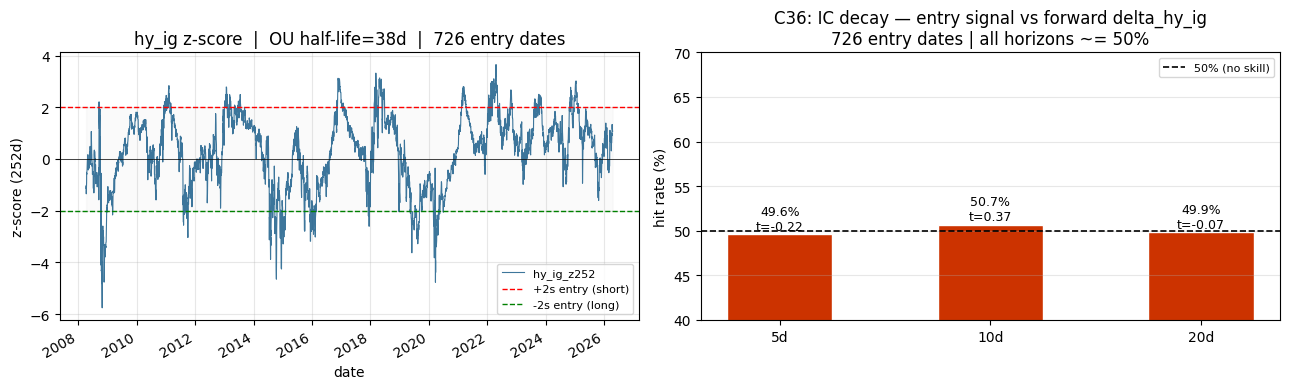

Figure 2: z-score time series and IC decay chart


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
z_hyig.plot(ax=ax, color='#1b5e8a', lw=0.8, alpha=0.85)
ax.axhline( 2, color='red',   ls='--', lw=1, label='+2s entry (short)')
ax.axhline(-2, color='green', ls='--', lw=1, label='-2s entry (long)')
ax.axhline( 0, color='black', lw=0.5)
ax.fill_between(z_hyig.index, -2, 2, alpha=0.04, color='grey')
ax.set_ylabel('z-score (252d)')
ax.set_title(f'hy_ig z-score  |  OU half-life={hl_z:.0f}d  |  {len(entry_dates)} entry dates')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax2 = axes[1]
hrs  = [results_c36[h][1] * 100 for h in [5, 10, 20]]
tsts = [results_c36[h][2] for h in [5, 10, 20]]
colors_b = ['#1b8a3a' if p else '#cc3300'
            for p in [results_c36[h][3] for h in [5, 10, 20]]]
bars = ax2.bar(['5d', '10d', '20d'], hrs, color=colors_b, edgecolor='white', width=0.5)
ax2.axhline(50, color='black', ls='--', lw=1.2, label='50% (no skill)')
ax2.set_ylim(40, 70); ax2.set_ylabel('hit rate (%)')
ax2.set_title(f'C36: IC decay — entry signal vs forward delta_hy_ig\n{len(entry_dates)} entry dates | all horizons ~= 50%')
for bar, hr, ts in zip(bars, hrs, tsts):
    ax2.text(bar.get_x() + bar.get_width()/2, hr + 0.5,
             f'{hr:.1f}%\nt={ts:.2f}', ha='center', fontsize=9)
ax2.legend(fontsize=8); ax2.grid(alpha=0.3, axis='y')
fig.tight_layout(); plt.show()
print("Figure 2: z-score time series and IC decay chart")

---
## Section 3 — Programme Conclusion

### What was found

In [6]:
print("=" * 62)
print("PROGRAMME CONCLUSION — Credit Trading Lab v6.6")
print("=" * 62)
print()
print("RESULT: No deployable mean-reversion signal found in the")
print("        current HY/IG ETF spread framework.")
print()
print("Sprint-by-sprint verdict:")
print()
print("  v5    RV1_A net Sharpe 0.591 (registered) ----- INVALID")
print("        57% of gross P&L was OLS model drift, not market")
print("        moves (sprint v6 factor attribution).")
print()
print("  v6.5  Fixed-entry accounting test:")
print("        RV1_A corrected Sharpe:  0.202  (R1 FAIL <0.40)")
print("        RV2_A corrected Sharpe: -0.108  (R1 FAIL, -$13M net)")
print("        RV3_A corrected Sharpe: -0.187  (R1 FAIL, -$11M net)")
print("        All Tier 1 admissions withdrawn.")
print()
print("  v6.6  Option B (hy_ig z-score, no OLS):")
print("        C32 PASS  delta_hy_ig stationary (p~=0)")
print("        C33 PASS  z-score half-life 37.6d")
print("        C36 FAIL  IC hit rate 49.6/50.7/49.9% at 5/10/20d")
print("                  Entry signal = coin flip")
print()
print("-" * 62)
print("RETAINED FINDINGS (valid, carry forward)")
print("-" * 62)
print()
print("1. Fixed-entry P&L accounting is mandatory.")
print("   Rolling residuals cannot be marked to market unless")
print("   model parameters are fixed at entry.")
print()
print("2. Rolling residuals (OLS, Kalman) embed an intercept that")
print("   re-centres during the hold period. The P&L this generates")
print("   is NOT tradeable — it is a statistical accounting artifact.")
print()
print("3. Rolling z-scores on price levels need out-of-sample IC")
print("   tests, not just stationarity / half-life diagnostics.")
print("   A z-score can be stationary (via rolling demeaning) while")
print("   having zero directional predictive content (C36).")
print()
print("4. hy_ig level does NOT predict forward spread direction")
print("   at 5/10/20d in the tested setup. The 252-day rolling mean")
print("   catches up to an I(1) level; this drives z-score reversion,")
print("   not actual price mean-reversion.")
print()
print("=" * 62)
print("[notebook clean]")

PROGRAMME CONCLUSION — Credit Trading Lab v6.6

RESULT: No deployable mean-reversion signal found in the
        current HY/IG ETF spread framework.

Sprint-by-sprint verdict:

  v5    RV1_A net Sharpe 0.591 (registered) ----- INVALID
        57% of gross P&L was OLS model drift, not market
        moves (sprint v6 factor attribution).

  v6.5  Fixed-entry accounting test:
        RV1_A corrected Sharpe:  0.202  (R1 FAIL <0.40)
        RV2_A corrected Sharpe: -0.108  (R1 FAIL, -$13M net)
        RV3_A corrected Sharpe: -0.187  (R1 FAIL, -$11M net)
        All Tier 1 admissions withdrawn.

  v6.6  Option B (hy_ig z-score, no OLS):
        C32 PASS  delta_hy_ig stationary (p~=0)
        C33 PASS  z-score half-life 37.6d
        C36 FAIL  IC hit rate 49.6/50.7/49.9% at 5/10/20d
                  Entry signal = coin flip

--------------------------------------------------------------
RETAINED FINDINGS (valid, carry forward)
--------------------------------------------------------------

1.